Cookie dough data set
===================

In [1]:
import pandas as ps
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, max_error
from twoblock import twoblock, rtb
from direpack import snipls
import dcor
import warnings
import matplotlib.pyplot as plt

In [2]:
Yt_full = ps.read_csv("../data/cookie_lab_train.csv", index_col=0).T
Xt_full = ps.read_csv("../data/cookie_nir_train.csv", index_col=0).T
Yv_full = ps.read_csv("../data/cookie_lab_test.csv", index_col=0).T
Xv_full = ps.read_csv("../data/cookie_nir_test.csv", index_col=0).T

# Clean data: remove 23rd case from train (index 22), 21st from test (index 20)
Xt = Xt_full.drop(Xt_full.index[22])
Yt = Yt_full.drop(Yt_full.index[22])
Xv = Xv_full.drop(Xv_full.index[20])
Yv = Yv_full.drop(Yv_full.index[20])
p = Xt.shape[1]
q = Yt.shape[1]

_PLS2_
-----------

In [3]:
gcv = GridSearchCV(PLSRegression(), {'n_components': range(1,20), 'scale':[True,False]}, scoring="r2")
gcv.fit(Xt,Yt)
gcv.best_params_

{'n_components': 6, 'scale': False}

In [4]:
Yptpls2 = gcv.predict(Xt)
Ypvpls2 = gcv.predict(Xv)
r2pls2t = [
    r2_score(Yt.iloc[:, i], Yptpls2[:, i]) for i in range(Yt.shape[1])
]
r2pls2t

[0.953214575472172, 0.9593743896483964, 0.9264246807066431, 0.9739406311208917]

In [5]:
r2pls2v = [
    r2_score(Yv.iloc[:, i], Ypvpls2[:, i]) for i in range(Yv.shape[1])
]
r2pls2v

[0.5504939505427381, 0.9476554496016836, 0.7455610720059216, 0.657818899863253]

_PLS1_
------

In [6]:
gcvs = [GridSearchCV(PLSRegression(), {'n_components': range(1,20), 'scale':[True,False]}).fit(Xt,Yt.iloc[:,i]) for i in range(q)]
[g.best_params_ for g in gcvs]

[{'n_components': 7, 'scale': True},
 {'n_components': 6, 'scale': False},
 {'n_components': 6, 'scale': False},
 {'n_components': 7, 'scale': True}]

In [7]:
Yptpls1 = np.array([g.predict(Xt) for g in gcvs]).T
Ypvpls1 = np.array([g.predict(Xv) for g in gcvs]).T
r2pls1t = [
    r2_score(Yt.iloc[:, i], Yptpls1[:, i]) for i in range(Yt.shape[1])
]
r2pls1t

[0.9753114423423631,
 0.9601047044971708,
 0.9303499853696122,
 0.9846043130354766]

In [8]:
r2pls1v = [
    r2_score(Yv.iloc[:, i], Ypvpls1[:, i]) for i in range(Yv.shape[1])
]
r2pls1v

[0.9789059749219043,
 0.9346550753506541,
 0.7299071095922096,
 0.9156008898582643]

_Twoblock_
-----------

_Dense_

In [9]:
gcvt = GridSearchCV(twoblock(), {'n_components_x': range(1,11), 'n_components_y': range(1,3), 'scale':["None","std"]}, scoring="r2", cv=5)
gcvt.fit(Xt,Yt)
gcvt.best_params_

{'n_components_x': 6, 'n_components_y': 2, 'scale': 'None'}

In [10]:
Ypttb = gcvt.predict(Xt)
Ypvtb = gcvt.predict(Xv)
r2tbt = [
    r2_score(Yt.iloc[:, i], Ypttb[:, i]) for i in range(Yt.shape[1])
]
# np.mean(r2tbt)/(10*(np.max(r2tbt)-np.min(r2tbt)))
r2tbt

[0.9526838673674178, 0.9591388843977839, 0.9232601405505823, 0.961881301113847]

In [11]:
r2tbv = [
    r2_score(Yv.iloc[:, i], Ypvtb[:, i]) for i in range(Yv.shape[1])
]
r2tbv

[0.5956646209336041,
 0.9403874486389319,
 0.8211564798649165,
 0.37851336591808693]

_Sparse_

In [ ]:
gcvt = GridSearchCV(twoblock(), {'n_components_x': range(1,7), 'n_components_y': range(1,3), 'sparse': [True], 'eta_x': np.arange(.6,.95,.05), 'scale':["std"]}, scoring="r2", cv=20)
gcvt.fit(Xt,Yt)
gcvt.best_params_

In [12]:
gcvt = twoblock(**{'n_components_x': 9, 'n_components_y': 2, 'eta_x': .5, 'eta_y':0, 'scale': 'std', 'sparse': True})

In [13]:
gcvt.fit(Xt,Yt)

C:\Users\SvenSerneels\venv\Suite\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:383: UserWarning: potentially wrong underline length... 
Parameters 
----------- in 
TWOBLOCK Dense and Sparse Two-Block Simultaneous Dimension Reduction of 
Multivariate X and Y data blocks...
  if not self._is_at_section():
C:\Users\SvenSerneels\venv\Suite\Lib\site-packages\sklearn\externals\_numpydoc\docscrape.py:203: UserWarning: potentially wrong underline length... 
Attributes 
------------ in 
TWOBLOCK Dense and Sparse Two-Block Simultaneous Dimension Reduction of 
Multivariate X and Y data blocks...
  while not self._is_at_section() and not self._doc.eof():


,n_components_x,9
,n_components_y,2
,centre,'mean'
,scale,'std'
,sparse,True
,eta_x,0.5
,eta_y,0
,verbose,True
,copy,True


In [14]:
Ypttbs = gcvt.predict(Xt)
Ypvtbs = gcvt.predict(Xv)
r2tbts = [
    r2_score(Yt.iloc[:, i], Ypttbs[:, i]) for i in range(Yt.shape[1])
]
np.mean(r2tbts)/(10*(np.max(r2tbts)-np.min(r2tbts)))
#r2tbts

np.float64(2.2238536028224853)

In [15]:
r2tbvs = [
    r2_score(Yv.iloc[:, i], Ypvtbs[:, i]) for i in range(Yv.shape[1])
]
r2tbvs

[0.9295719066702044,
 0.9616877602354748,
 0.9310166251922251,
 0.9480401387839028]

In [16]:
pct_x_tb = 100 * len(gcvt.x_indret_) / Xt.shape[1]
print(f"X variables retained: {len(gcvt.x_indret_)} / {Xt.shape[1]} ({pct_x_tb:.1f}%)")

X variables retained: 700 / 700 (100.0%)


_Robust Twoblock (RTB)_
-----------

_Dense_

In [ ]:
# Cross-validate dense RTB on full data (including outliers)
gcv_rtb = GridSearchCV(rtb(verbose=False), 
                       {'n_components_x': range(1, 12), 'n_components_y': range(1, 3), 
                        'scale': ['kstepLTS', 'None'], 'probp1': [.75], 'probp2': [.9], 'probp3': [.95]}, 
                       scoring="r2", cv=20)
gcv_rtb.fit(Xt_full, Yt_full)
gcv_rtb.best_params_

In [81]:
Ypt_rtb = gcv_rtb.predict(Xt_full)
Ypv_rtb = gcv_rtb.predict(Xv)
r2_rtb_t = [
    r2_score(Yt_full.iloc[:, i], Ypt_rtb[:, i]) for i in range(Yt_full.shape[1])
]
r2_rtb_t

[0.9662017056795191,
 0.8694804870819243,
 0.8292986778446381,
 0.9044937495211768]

In [82]:
r2_rtb_v = [
    r2_score(Yv.iloc[:, i], Ypv_rtb[:, i]) for i in range(Yv.shape[1])
]
r2_rtb_v

[0.9331827350549426, 0.9084928914860759, 0.838792348876473, 0.8229779224888293]

In [84]:
gcv_rtb.best_estimator_.caseweights_

array([1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00,
       1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00,
       1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e-06, 1.e-06,
       1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00,
       1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00, 1.e+00])

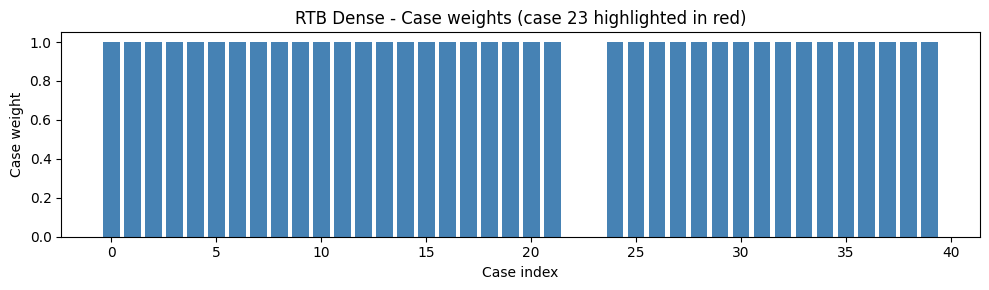

In [86]:
import matplotlib.pyplot as plt

colors = ['red' if i == 22 else 'steelblue' for i in range(len(gcv_rtb.best_estimator_.caseweights_))]
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(gcv_rtb.best_estimator_.caseweights_)), gcv_rtb.best_estimator_.caseweights_, color=colors)
ax.set_xlabel('Case index')
ax.set_ylabel('Case weight')
ax.set_title('RTB Dense - Case weights (case 23 highlighted in red)')
plt.tight_layout()
plt.show()

_Sparse_

In [ ]:
# Cross-validate sparse RTB on full data (including outliers)
gcv_rtbs = GridSearchCV(rtb(verbose=False), 
                        {'n_components_x': range(1, 9), 'n_components_y': range(1, 3),
                         'sparse': [True], 'eta_x': [.3, .5, .7], 'eta_y': [0],
                         'scale': ['kstepLTS', 'None'], 'probp1': [.75], 'probp2': [.9], 'probp3': [.95]}, 
                        scoring="r2", cv=20)
gcv_rtbs.fit(Xt_full, Yt_full)
gcv_rtbs.best_params_

In [97]:
Ypt_rtbs = gcv_rtbs.predict(Xt_full)
Ypv_rtbs = gcv_rtbs.predict(Xv)
r2_rtbs_t = [
    r2_score(Yt_full.iloc[:, i], Ypt_rtbs[:, i]) for i in range(Yt_full.shape[1])
]
r2_rtbs_t

[0.9670098336404999,
 0.8366631284017014,
 0.7944703396485856,
 0.8952861563829062]

In [98]:
r2_rtbs_v = [
    r2_score(Yv.iloc[:, i], Ypv_rtbs[:, i]) for i in range(Yv_full.shape[1])
]
r2_rtbs_v

[0.9796316913030001,
 0.9137088192132059,
 0.8763797178549319,
 0.9041813063571073]

In [100]:
best_rtbs = gcv_rtbs.best_estimator_
pct_x = 100 * len(best_rtbs.x_colret_) / Xt_full.shape[1]
print(f"X variables retained: {len(best_rtbs.x_colret_)} / {Xt_full.shape[1]} ({pct_x:.1f}%)")

AttributeError: 'rtb' object has no attribute 'x_colret_'

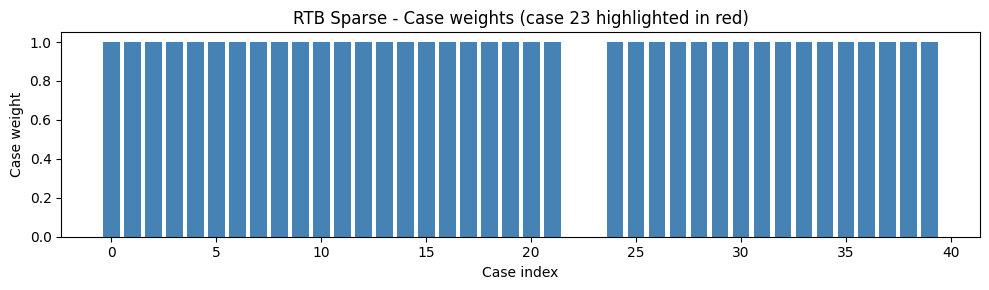

In [101]:
colors = ['red' if i == 22 else 'steelblue' for i in range(len(best_rtbs.caseweights_))]
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(best_rtbs.caseweights_)), best_rtbs.caseweights_, color=colors)
ax.set_xlabel('Case index')
ax.set_ylabel('Case weight')
ax.set_title('RTB Sparse - Case weights (case 23 highlighted in red)')
plt.tight_layout()
plt.show()

In [102]:
zero_vars = np.where(gcv_rtbs.best_estimator_.x_loadings_[:,-1] < 1e-7)[0]

In [103]:
len(zero_vars)

368

In [104]:
def find_consecutive_intervals(numbers):
    if not numbers:
        return []

    # Sort the numbers to ensure they are in order
    numbers = sorted(numbers)
    intervals = []
    start = numbers[0]
    end = numbers[0]

    for i in range(1, len(numbers)):
        if numbers[i] == end + 1:
            end = numbers[i]
        else:
            intervals.append((start, end))
            start = numbers[i]
            end = numbers[i]

    intervals.append((start, end))
    return intervals

In [105]:
wavelength_intervals = find_consecutive_intervals(zero_vars.tolist())
wavelength_intervals

[(0, 26), (165, 215), (302, 341), (397, 646)]

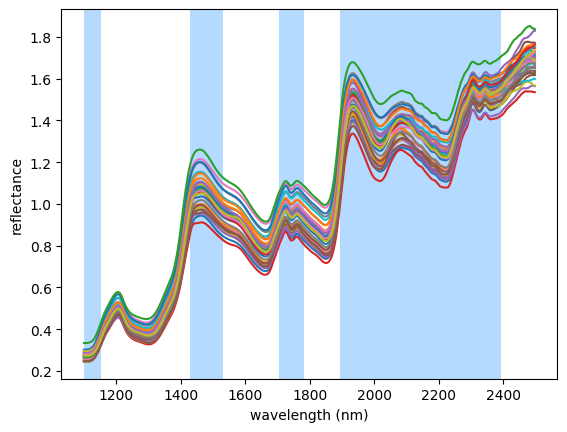

In [107]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(Xt.transpose())
for w in wavelength_intervals:
    ax.axvspan(Xt.columns[w[0]], Xt.columns[w[1]], facecolor="dodgerblue", alpha=0.33)
plt.xlabel("wavelength (nm)")
plt.ylabel("reflectance") 
plt.savefig('Eliminated_wavelengths.pdf')

In [108]:
zero_vars_coeff = np.where(gcv_rtbs.best_estimator_.coef_[:,-1] < 1e-7)[0]

In [109]:
zero_vars_coeff

array([  9,  10,  11,  12,  13,  14,  15,  16,  17,  18,  19,  20,  21,
        22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,
        35,  36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,
        48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,
        61,  62,  63,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
       207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219,
       220, 221, 222, 223, 289, 290, 291, 292, 293, 294, 295, 296, 297,
       298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310,
       311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323,
       324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 334, 33